## CCLE Metabolomics — `12_CCLE_metabolomics_20190502.csv`

928 cell lines × 225 metabolite measurements (amino acids, lipids, TAG lipid species). Captures what the cell is producing and consuming — a different angle from gene expression. Values are log-transformed. Join to other files via `DepMap_ID` (`ACH-...`); ~0.1% of rows lack it, fall back to `CCLE_ID`.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df12)

In [3]:
df.head()

,CCLE_ID,DepMap_ID,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
0,DMS53_LUNG,ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
1,SW1116_LARGE_INTESTINE,ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
2,NCIH1694_LUNG,ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
3,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
4,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260


### DepMap_ID coverage and basic structure
We need DepMap_ID to join metabolomics to other datasets.

In [4]:
meta_cols = ["CCLE_ID", "DepMap_ID"]
met_cols  = [c for c in df.columns if c not in meta_cols]
print(f"Shape            : {df.shape}")
print(f"Metabolites      : {len(met_cols)}")
print(f"Missing DepMap_ID: {df['DepMap_ID'].isna().sum()}")
print(f"Value range      : {df[met_cols].min().min():.2f} – {df[met_cols].max().max():.2f}")


Shape            : (928, 227)
Metabolites      : 225
Missing DepMap_ID: 1
Value range      : 2.98 – 9.10


### Value distribution
Values should be log-transformed already. A bell-shaped distribution centred ~5-7 is expected.

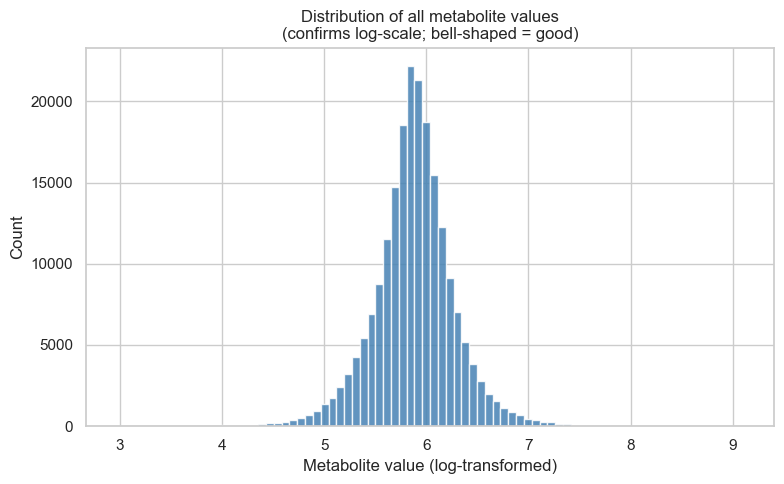

In [5]:
sample_vals = df[met_cols].values.flatten()
sample_vals = sample_vals[~np.isnan(sample_vals)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sample_vals, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Metabolite value (log-transformed)")
ax.set_ylabel("Count")
ax.set_title("Distribution of all metabolite values\n(confirms log-scale; bell-shaped = good)")
plt.tight_layout(); plt.show()


### Per-cell-line mean metabolite level
Shows how metabolically active each cell line is on average.

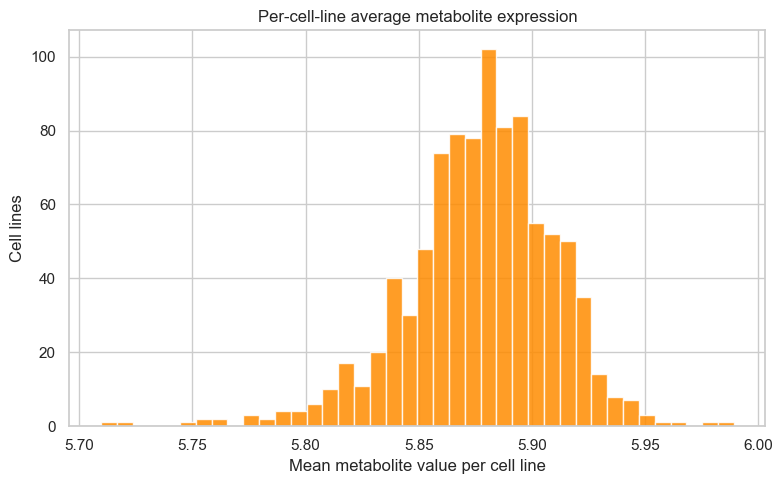

In [6]:
row_means = df[met_cols].mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(row_means, bins=40, color="darkorange", edgecolor="white", alpha=0.85)
ax.set_xlabel("Mean metabolite value per cell line")
ax.set_ylabel("Cell lines")
ax.set_title("Per-cell-line average metabolite expression")
plt.tight_layout(); plt.show()


### Most variable metabolites
High-variance metabolites distinguish cell lines from each other — the most informative features for modelling.

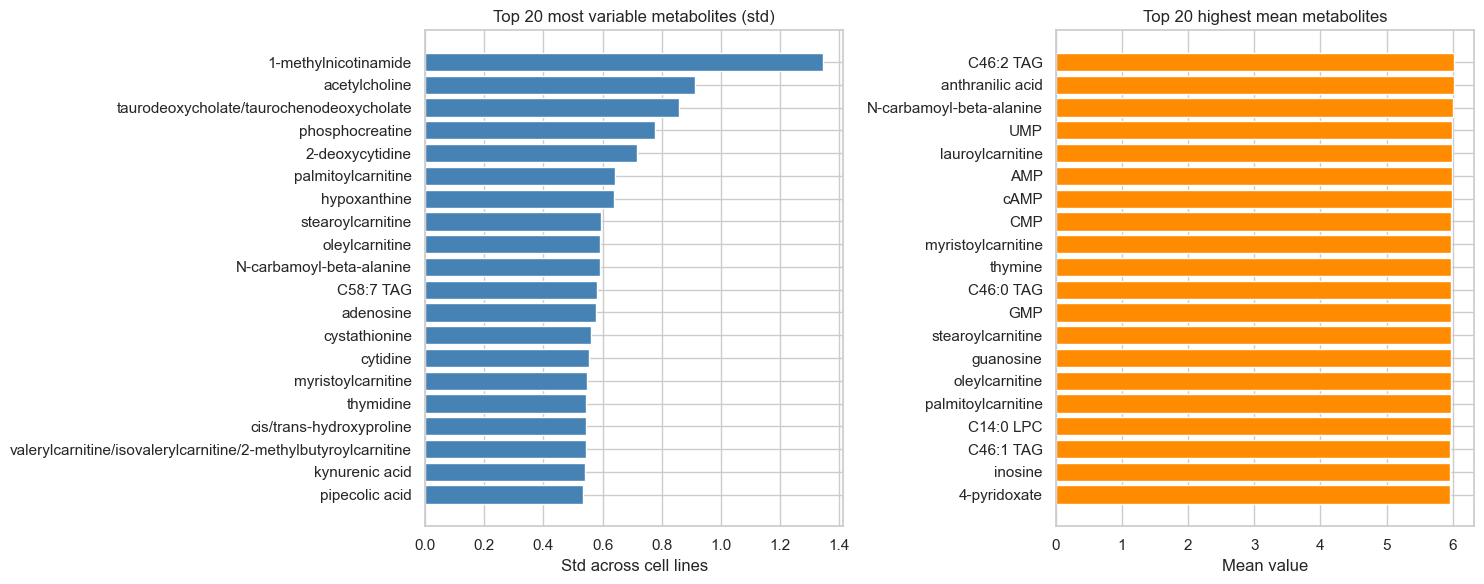

In [7]:
met_std  = df[met_cols].std().sort_values(ascending=False)
met_mean = df[met_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(met_std.head(20).index[::-1], met_std.head(20).values[::-1], color="steelblue")
axes[0].set_title("Top 20 most variable metabolites (std)")
axes[0].set_xlabel("Std across cell lines")

axes[1].barh(met_mean.head(20).index[::-1], met_mean.head(20).values[::-1], color="darkorange")
axes[1].set_title("Top 20 highest mean metabolites")
axes[1].set_xlabel("Mean value")

plt.tight_layout(); plt.show()


### PCA of cell lines by metabolome
Each dot is a cell line; nearby dots have similar metabolic profiles.

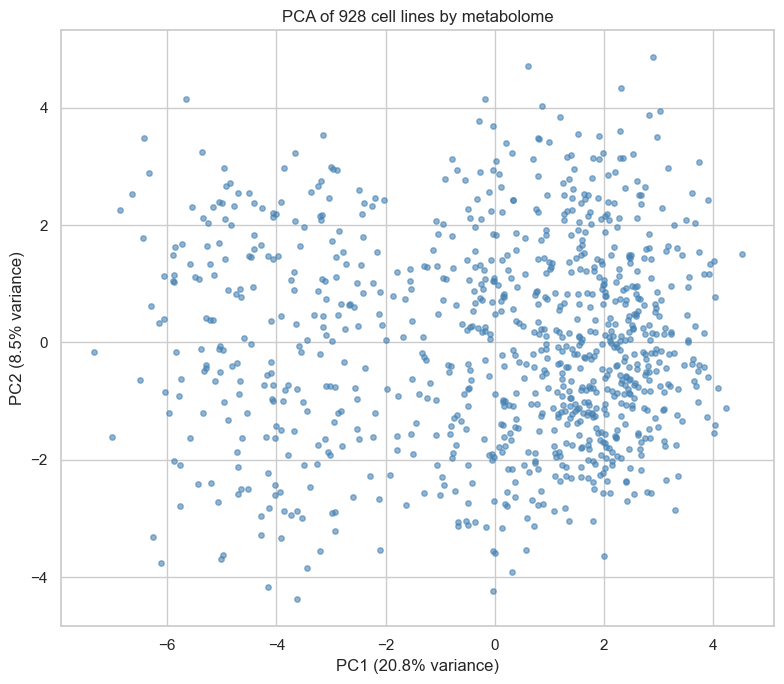

In [8]:
X = df[met_cols].dropna(axis=1)  # drop any metabolite with any NaN
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=15, color="steelblue")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)")
ax.set_title("PCA of 928 cell lines by metabolome")
plt.tight_layout(); plt.show()


### Metabolite correlation clustermap
Groups co-regulated metabolites. Amino acid clusters and lipid clusters should be visible.

<Figure size 1400x1200 with 0 Axes>

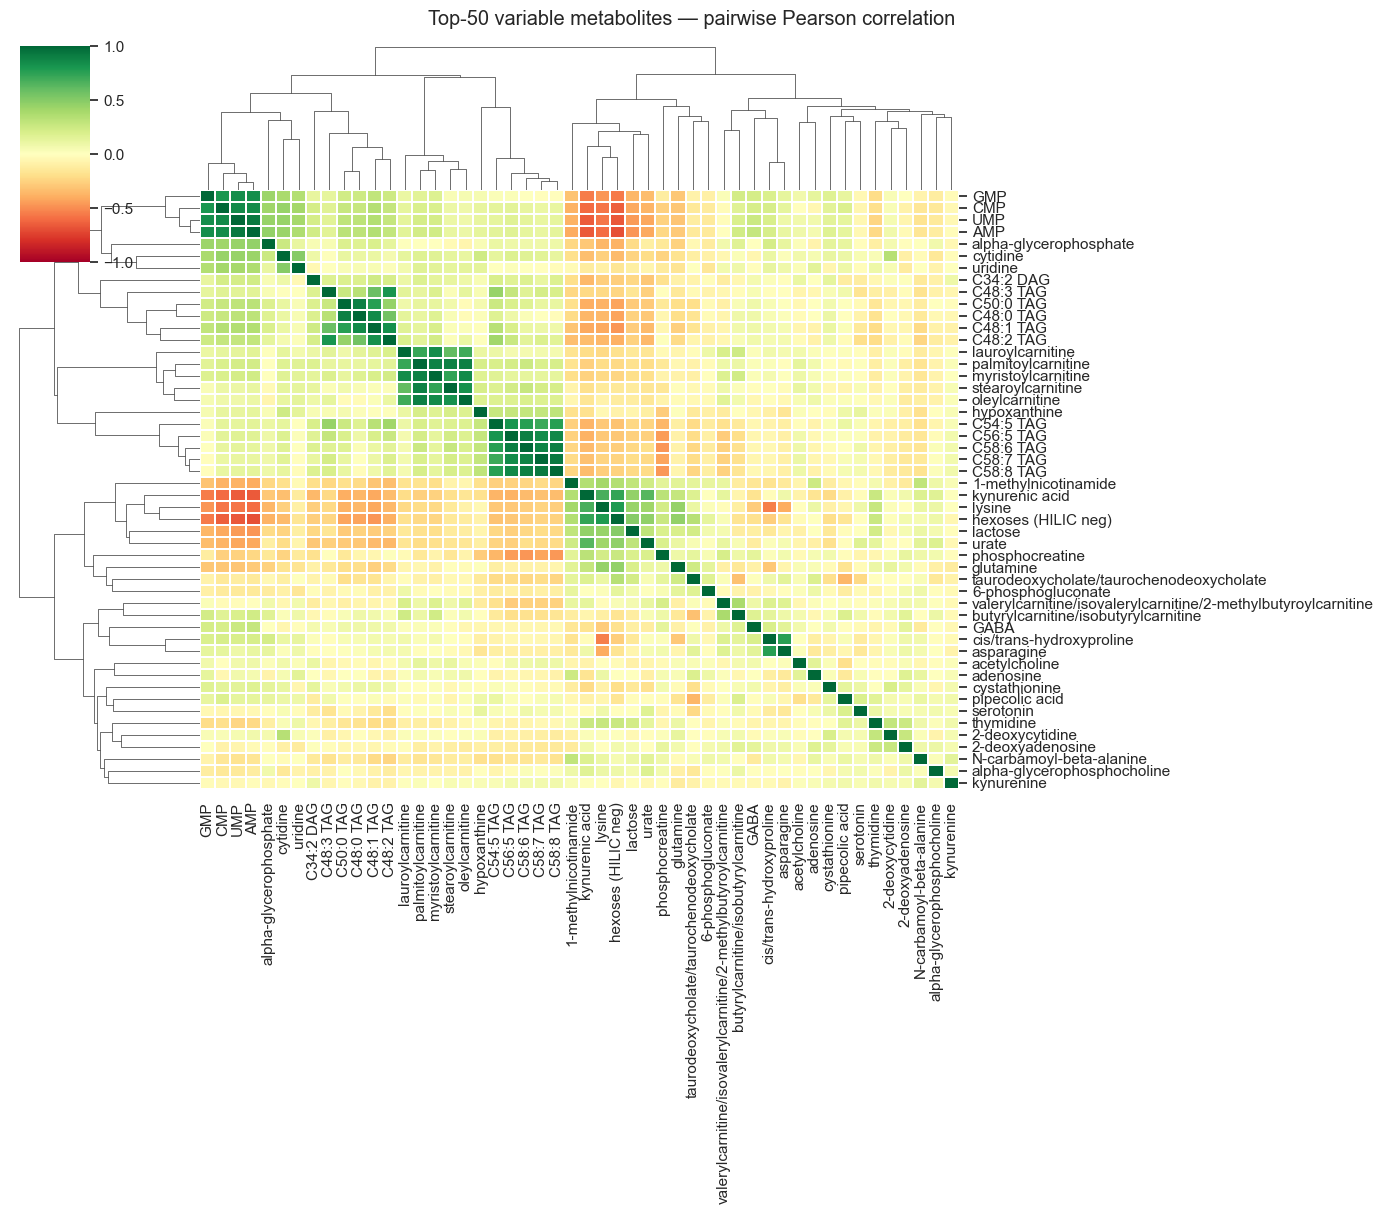

In [9]:
top50 = met_std.head(50).index
corr50 = df[top50].corr()

fig = plt.figure(figsize=(14, 12))
sns.clustermap(corr50, cmap="RdYlGn", center=0, vmin=-1, vmax=1,
               figsize=(14, 12), xticklabels=True, yticklabels=True,
               linewidths=0.3)
plt.suptitle("Top-50 variable metabolites — pairwise Pearson correlation", y=1.01)
plt.show()


### Key findings

In [10]:
print("=== CCLE Metabolomics ===")
print(f"Cell lines        : {len(df)}")
print(f"Metabolites       : {len(met_cols)}")
print(f"Missing DepMap_ID : {df['DepMap_ID'].isna().sum()}")
print(f"PCA PC1+PC2       : {sum(pca.explained_variance_ratio_)*100:.1f}% variance explained")
print(f"Most variable     : {met_std.idxmax()} (std={met_std.max():.3f})")


=== CCLE Metabolomics ===
Cell lines        : 928
Metabolites       : 225
Missing DepMap_ID : 1
PCA PC1+PC2       : 29.3% variance explained
Most variable     : 1-methylnicotinamide (std=1.347)


## Join Analysis — how this table connects to the others

df12 has BOTH `DepMap_ID` (ACH-) and `CCLE_ID` (NAME_TISSUE) — two independent join
paths to df9. df13 (miRNA) uses `CCLE_ID` to join via df12.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df12 | `DepMap_ID` | df9 | `DepMap_ID` | 1:1 | primary join |
| df12 | `CCLE_ID` | df9 | `CCLE_Name` | 1:1 | fallback join |
| df13 | cell line cols (NAME_TISSUE) | df12 | `CCLE_ID` | 1:1 | miRNA → metabolomics |
| df12 via df9 | ModelID | df2 via df8 | ModelID | 1:1 | metabolomics + RNA |

**Biological note:** `CCLE_ID` is in `NAME_TISSUE` format (e.g., `DMS53_LUNG`).
Small name inconsistencies (e.g., `HCC827` vs `HCC827GR5`) will break this join —
always check for partial matches when debugging.


In [11]:
# ── A/B: Join coverage df12 → df9 (both paths) ──────────────────────────────
meta_cols = ["CCLE_ID","DepMap_ID"]
df9_ids   = pd.read_csv(ini.df9, usecols=["DepMap_ID","CCLE_Name","lineage"])

df9_depmap = set(df9_ids["DepMap_ID"].dropna())
df9_ccle   = set(df9_ids["CCLE_Name"].dropna())

df12_depmap = set(df["DepMap_ID"].dropna())
df12_ccle   = set(df["CCLE_ID"].dropna())

# Primary join (DepMap_ID)
match_primary = df12_depmap & df9_depmap
lost_primary  = df12_depmap - df9_depmap
# Fallback join (CCLE_ID) for rows that failed primary
df12_no_depmap = df[df["DepMap_ID"].isna()]
match_fallback = set(df12_no_depmap["CCLE_ID"].dropna()) & df9_ccle

# miRNA side: df13 cell line columns → df12 CCLE_ID
df13_raw  = pd.read_csv(ini.df13, sep="\t", skiprows=2, index_col=0, nrows=1)
mir_lines = set(c for c in df13_raw.columns if c != "Description")
match_mir = mir_lines & df12_ccle

print("=== df12 join coverage ===")
print(f"df12 rows                           : {len(df)}")
print(f"Primary join (DepMap_ID → df9)      : {len(match_primary)} ({len(match_primary)/len(df12_depmap)*100:.1f}%)")
print(f"  Lost in primary join              : {len(lost_primary)}")
print(f"  Rows with missing DepMap_ID       : {df['DepMap_ID'].isna().sum()}")
print(f"Fallback join (CCLE_ID → df9)       : {len(match_fallback)}")
print()
print(f"df13 miRNA cell lines               : {len(mir_lines)}")
print(f"  Matched in df12 via CCLE_ID       : {len(match_mir)} ({len(match_mir)/len(mir_lines)*100:.1f}%)")
print(f"  miRNA lines not in df12           : {len(mir_lines - df12_ccle)}")


=== df12 join coverage ===
df12 rows                           : 928
Primary join (DepMap_ID → df9)      : 927 (100.0%)
  Lost in primary join              : 0
  Rows with missing DepMap_ID       : 1
Fallback join (CCLE_ID → df9)       : 1

df13 miRNA cell lines               : 954
  Matched in df12 via CCLE_ID       : 914 (95.8%)
  miRNA lines not in df12           : 40


In [12]:
# ── C: Format check — CCLE_ID naming consistency df12 vs df9 ─────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["DepMap_ID"].dropna(), "DepMap_ID (df12)", prefix="ACH-")
print()
fmt_check(df["CCLE_ID"].dropna(), "CCLE_ID (df12)")
print()
fmt_check(df9_ids["CCLE_Name"].dropna(), "CCLE_Name (df9)")
print()
# Spot check: CCLE_ID in df12 vs CCLE_Name in df9 format comparison
sample_df12 = sorted(df["CCLE_ID"].dropna())[:5]
sample_df9  = sorted(df9_ids["CCLE_Name"].dropna())[:5]
print(f"df12 CCLE_ID sample  : {sample_df12}")
print(f"df9  CCLE_Name sample: {sample_df9}")
print()
# Cross-format: are there case differences?
df12_ccle_lower = {x.lower() for x in df12_ccle}
df9_ccle_lower  = {x.lower() for x in df9_ccle}
case_match = df12_ccle_lower & df9_ccle_lower
exact_match = df12_ccle & df9_ccle
print(f"Exact CCLE_ID match (df12 vs df9)      : {len(exact_match)}")
print(f"Case-insensitive match                  : {len(case_match)}")
print(f"Extra matches via case-fold             : {len(case_match) - len(exact_match)}")


Format check — DepMap_ID (df12) (n=927 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — CCLE_ID (df12) (n=928 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  Length range        : 8 – 46
  Duplicates          : 0

Format check — CCLE_Name (df9) (n=1836 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  Length range        : 7 – 54
  Duplicates          : 0

df12 CCLE_ID sample  : ['22RV1_PROSTATE', '2313287_STOMACH', '253JBV_URINARY_TRACT', '253J_URINARY_TRACT', '42MGBA_CENTRAL_NERVOUS_SYSTEM']
df9  CCLE_Name sample: ['127399_SOFT_TISSUE', '1321N1_CENTRAL_NERVOUS_SYSTEM', '143B_BONE', '170MGBA_CENTRAL_NERVOUS_SYSTEM', '184A1_BREAST']

Exact CCLE_ID match (df12 vs df9)      : 925
Case-insensitive match                  : 925
Extra matches via case-fold             : 0


### Biological implications

Metabolomics covers ~50% of df9 lines. The uncovered 50% cannot be used in a
combined metabolomics + expression model. If the covered 50% is not representative
(e.g., over-represented in certain lineages), the model will be biased.


In [13]:
# Biological: lineage representation comparison
covered   = df9_ids[df9_ids["DepMap_ID"].isin(match_primary)]
uncovered = df9_ids[~df9_ids["DepMap_ID"].isin(match_primary)]

total_per   = df9_ids["lineage"].value_counts()
covered_per = covered["lineage"].value_counts()
pct = (covered_per / total_per * 100).dropna().sort_values()

print("Metabolomics coverage % per lineage (lowest first):")
print(pct.head(10).round(1).to_string())
print()
print("Uncovered lineages (top 10 most missing):")
print(uncovered["lineage"].value_counts().head(10).to_string())


Metabolomics coverage % per lineage (lowest first):
lineage
unknown                       2.1
bile_duct                    18.6
bone                         20.3
soft_tissue                  21.1
fibroblast                   33.3
peripheral_nervous_system    33.3
upper_aerodigestive          40.5
skin                         42.5
kidney                       43.3
central_nervous_system       45.9

Uncovered lineages (top 10 most missing):
lineage
lung                      92
skin                      69
bone                      63
blood                     59
central_nervous_system    59
soft_tissue               56
lymphocyte                55
upper_aerodigestive       47
unknown                   46
breast                    38


## Join Analysis — how this table connects to the others

df12 has BOTH `DepMap_ID` (ACH-) and `CCLE_ID` (NAME_TISSUE) — two independent join
paths to df9. df13 (miRNA) uses `CCLE_ID` to join via df12.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df12 | `DepMap_ID` | df9 | `DepMap_ID` | 1:1 | primary join |
| df12 | `CCLE_ID` | df9 | `CCLE_Name` | 1:1 | fallback join |
| df13 | cell line cols (NAME_TISSUE) | df12 | `CCLE_ID` | 1:1 | miRNA → metabolomics |
| df12 via df9 | ModelID | df2 via df8 | ModelID | 1:1 | metabolomics + RNA |

**Biological note:** `CCLE_ID` is in `NAME_TISSUE` format (e.g., `DMS53_LUNG`).
Small name inconsistencies (e.g., `HCC827` vs `HCC827GR5`) will break this join —
always check for partial matches when debugging.


In [14]:
# ── A/B: Join coverage df12 → df9 (both paths) ──────────────────────────────
meta_cols = ["CCLE_ID","DepMap_ID"]
df9_ids   = pd.read_csv(ini.df9, usecols=["DepMap_ID","CCLE_Name","lineage"])

df9_depmap = set(df9_ids["DepMap_ID"].dropna())
df9_ccle   = set(df9_ids["CCLE_Name"].dropna())

df12_depmap = set(df["DepMap_ID"].dropna())
df12_ccle   = set(df["CCLE_ID"].dropna())

# Primary join (DepMap_ID)
match_primary = df12_depmap & df9_depmap
lost_primary  = df12_depmap - df9_depmap
# Fallback join (CCLE_ID) for rows that failed primary
df12_no_depmap = df[df["DepMap_ID"].isna()]
match_fallback = set(df12_no_depmap["CCLE_ID"].dropna()) & df9_ccle

# miRNA side: df13 cell line columns → df12 CCLE_ID
df13_raw  = pd.read_csv(ini.df13, sep="\t", skiprows=2, index_col=0, nrows=1)
mir_lines = set(c for c in df13_raw.columns if c != "Description")
match_mir = mir_lines & df12_ccle

print("=== df12 join coverage ===")
print(f"df12 rows                           : {len(df)}")
print(f"Primary join (DepMap_ID → df9)      : {len(match_primary)} ({len(match_primary)/len(df12_depmap)*100:.1f}%)")
print(f"  Lost in primary join              : {len(lost_primary)}")
print(f"  Rows with missing DepMap_ID       : {df['DepMap_ID'].isna().sum()}")
print(f"Fallback join (CCLE_ID → df9)       : {len(match_fallback)}")
print()
print(f"df13 miRNA cell lines               : {len(mir_lines)}")
print(f"  Matched in df12 via CCLE_ID       : {len(match_mir)} ({len(match_mir)/len(mir_lines)*100:.1f}%)")
print(f"  miRNA lines not in df12           : {len(mir_lines - df12_ccle)}")


=== df12 join coverage ===
df12 rows                           : 928
Primary join (DepMap_ID → df9)      : 927 (100.0%)
  Lost in primary join              : 0
  Rows with missing DepMap_ID       : 1
Fallback join (CCLE_ID → df9)       : 1

df13 miRNA cell lines               : 954
  Matched in df12 via CCLE_ID       : 914 (95.8%)
  miRNA lines not in df12           : 40


In [15]:
# ── C: Format check — CCLE_ID naming consistency df12 vs df9 ─────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["DepMap_ID"].dropna(), "DepMap_ID (df12)", prefix="ACH-")
print()
fmt_check(df["CCLE_ID"].dropna(), "CCLE_ID (df12)")
print()
fmt_check(df9_ids["CCLE_Name"].dropna(), "CCLE_Name (df9)")
print()
# Spot check: CCLE_ID in df12 vs CCLE_Name in df9 format comparison
sample_df12 = sorted(df["CCLE_ID"].dropna())[:5]
sample_df9  = sorted(df9_ids["CCLE_Name"].dropna())[:5]
print(f"df12 CCLE_ID sample  : {sample_df12}")
print(f"df9  CCLE_Name sample: {sample_df9}")
print()
# Cross-format: are there case differences?
df12_ccle_lower = {x.lower() for x in df12_ccle}
df9_ccle_lower  = {x.lower() for x in df9_ccle}
case_match = df12_ccle_lower & df9_ccle_lower
exact_match = df12_ccle & df9_ccle
print(f"Exact CCLE_ID match (df12 vs df9)      : {len(exact_match)}")
print(f"Case-insensitive match                  : {len(case_match)}")
print(f"Extra matches via case-fold             : {len(case_match) - len(exact_match)}")


Format check — DepMap_ID (df12) (n=927 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — CCLE_ID (df12) (n=928 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  Length range        : 8 – 46
  Duplicates          : 0

Format check — CCLE_Name (df9) (n=1836 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  Length range        : 7 – 54
  Duplicates          : 0

df12 CCLE_ID sample  : ['22RV1_PROSTATE', '2313287_STOMACH', '253JBV_URINARY_TRACT', '253J_URINARY_TRACT', '42MGBA_CENTRAL_NERVOUS_SYSTEM']
df9  CCLE_Name sample: ['127399_SOFT_TISSUE', '1321N1_CENTRAL_NERVOUS_SYSTEM', '143B_BONE', '170MGBA_CENTRAL_NERVOUS_SYSTEM', '184A1_BREAST']

Exact CCLE_ID match (df12 vs df9)      : 925
Case-insensitive match                  : 925
Extra matches via case-fold             : 0


### Biological implications

Metabolomics covers ~50% of df9 lines. The uncovered 50% cannot be used in a
combined metabolomics + expression model. If the covered 50% is not representative
(e.g., over-represented in certain lineages), the model will be biased.


In [16]:
# Biological: lineage representation comparison
covered   = df9_ids[df9_ids["DepMap_ID"].isin(match_primary)]
uncovered = df9_ids[~df9_ids["DepMap_ID"].isin(match_primary)]

total_per   = df9_ids["lineage"].value_counts()
covered_per = covered["lineage"].value_counts()
pct = (covered_per / total_per * 100).dropna().sort_values()

print("Metabolomics coverage % per lineage (lowest first):")
print(pct.head(10).round(1).to_string())
print()
print("Uncovered lineages (top 10 most missing):")
print(uncovered["lineage"].value_counts().head(10).to_string())


Metabolomics coverage % per lineage (lowest first):
lineage
unknown                       2.1
bile_duct                    18.6
bone                         20.3
soft_tissue                  21.1
fibroblast                   33.3
peripheral_nervous_system    33.3
upper_aerodigestive          40.5
skin                         42.5
kidney                       43.3
central_nervous_system       45.9

Uncovered lineages (top 10 most missing):
lineage
lung                      92
skin                      69
bone                      63
blood                     59
central_nervous_system    59
soft_tissue               56
lymphocyte                55
upper_aerodigestive       47
unknown                   46
breast                    38


## Deeper dive: metabolome PCA coloured by lineage

The base PCA showed cell lines spread in metabolite space but couldn't say whether the
structure is biological. Colouring by lineage reveals whether tissue of origin drives
the metabolome (some metabolic phenotypes are strongly lineage-linked).

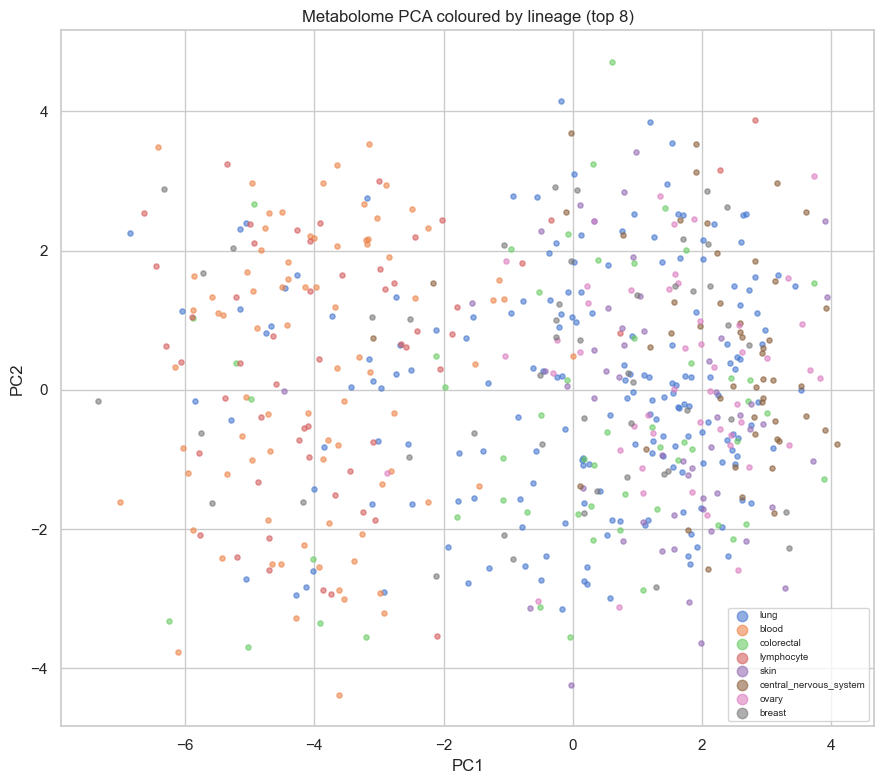

In [17]:
import __init__ as ini
from sklearn.decomposition import PCA
lin = pd.read_csv(ini.df9, usecols=["DepMap_ID","lineage"]).set_index("DepMap_ID")["lineage"]
X = df[met_cols].dropna(axis=1)
coords = PCA(n_components=2, random_state=42).fit_transform(X.values)
lins = np.array(df["DepMap_ID"].map(lin))
topL = pd.Series(lins).value_counts().head(8).index
fig, ax = plt.subplots(figsize=(9,8))
for l in topL:
    m = lins == l
    ax.scatter(coords[m,0], coords[m,1], s=14, alpha=0.6, label=l)
ax.legend(fontsize=7, markerscale=2); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Metabolome PCA coloured by lineage (top 8)")
plt.tight_layout(); plt.show()

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
If gene activity is the *instructions* and proteins are the *machines*, **metabolites are the cell's chemistry — the small molecules it's actively making and burning** (amino acids, fats, sugars). This file is essentially a **"blood test" for each of 928 cell lines**: a snapshot of 225 of these chemicals. It captures the cell's **metabolic personality**, a different angle than genes or proteins.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **928 cell lines × 225 metabolites**, keyed by `DepMap_ID` (with `CCLE_ID` as a backup key).
- Values are **already log-scaled** and there are **no missing values** within the metabolite columns — unusually clean.
- A PCA explained ~29% of the spread, and cell lines partly grouped by tissue — so there's real biological structure.
- **Coverage is only ~50% of the master catalogue**, and it's **biased by tissue** (some lineages barely covered).

Next steps (preprocessing):
- **Join via `DepMap_ID`** (fall back to `CCLE_ID` for the 1 orphan row).
- **Keep the log-scaling as-is**; optionally standardize per metabolite.
- **Decide the coverage strategy**: treat metabolomics as an **optional layer** present for ~half the lines, rather than imputing the missing half (imputing 50% would be inventing data).

Still missing in EDA:
- A **documented decision** on whether (and how) to fill the missing 50%, or to simply mark metabolomics as "available / not available" per line.

### 3. Which ML approach fits this dataset
**Unsupervised feature source — a secondary layer.** It enriches the picture of a cell line where available, but its ~50% coverage and tissue bias mean it can't be a primary signal; the model must rank well even when a line has no metabolomics.

> **Big-picture note:** Metabolomics is one of the **enrichment layers** on the DepMap spine (alongside proteomics and miRNA), used to strengthen the *why* behind a pick when the data exists.